In [58]:
import matplotlib.pyplot as plt
import numpy as np
import sys

#Read the MLWF cell map, weights and Hamiltonian:    
cellMap = np.loadtxt("wannier.mlwfCellMap")[:,0:3].astype(int)
Wwannier = np.fromfile("wannier.mlwfCellWeights")
nCells = cellMap.shape[0]
nBands = int(np.sqrt(Wwannier.shape[0] / nCells))
Wwannier = Wwannier.reshape((nCells,nBands,nBands)).swapaxes(1,2)
#--- Get k-point folding from totalE.out:
for line in open('totalE.out'):
    if line.startswith('kpoint-folding'):
        kfold = np.array([int(tok) for tok in line.split()[1:4]])
kfoldProd = np.prod(kfold)
kStride = np.array([kfold[1]*kfold[2], kfold[2], 1])
#--- Read reduced Wannier Hamiltonian, momenta and expand them:
Hreduced = np.fromfile("wannier.mlwfH").reshape((kfoldProd,nBands,nBands)).swapaxes(1,2)
Preduced = np.fromfile("wannier.mlwfP").reshape((kfoldProd,3,nBands,nBands)).swapaxes(2,3)
iReduced = np.dot(np.mod(cellMap, kfold[None,:]), kStride)
Hwannier = Wwannier * Hreduced[iReduced]
Pwannier = Wwannier[:,None] * Preduced[iReduced]

#Read phonon dispersion relation:
cellMapPh = np.loadtxt('totalE.phononCellMap', usecols=[0,1,2]).astype(int)
nCellsPh = cellMapPh.shape[0]
omegaSqR = np.fromfile('totalE.phononOmegaSq') #just a list of numbers
nModes = int(np.sqrt(omegaSqR.shape[0] // nCellsPh))
omegaSqR = omegaSqR.reshape((nCellsPh, nModes, nModes)).swapaxes(1,2)

#Read e-ph matrix elements
cellMapEph = np.loadtxt('wannier.mlwfCellMapPh', usecols=[0,1,2]).astype(int)
nCellsEph = cellMapEph.shape[0]
#--- Get phonon supercell from phonon.out:
for line in open('phonon.out'):
    tokens = line.split()
    if len(tokens)==5:
        if tokens[0]=='supercell' and tokens[4]=='\\':
            phononSup = np.array([int(token) for token in tokens[1:4]])
prodPhononSup = np.prod(phononSup)
phononSupStride = np.array([phononSup[1]*phononSup[2], phononSup[2], 1])
#--- Read e-ph cell weights:
nAtoms = nModes // 3
cellWeightsEph = np.fromfile("wannier.mlwfCellWeightsPh").reshape((nCellsEph,nBands,nAtoms)).swapaxes(1,2)
cellWeightsEph = np.repeat(cellWeightsEph.reshape((nCellsEph,nAtoms,1,nBands)), 3, axis=2) #repeat atom weights for 3 directions
cellWeightsEph = cellWeightsEph.reshape((nCellsEph,nModes,nBands)) #coombine nAtoms x 3 into single dimension: nModes
#--- Read, reshape and expand e-ph matrix elements:
iReducedEph = np.dot(np.mod(cellMapEph, phononSup[None,:]), phononSupStride)
HePhReduced = np.fromfile('wannier.mlwfHePh').reshape((prodPhononSup,prodPhononSup,nModes,nBands,nBands)).swapaxes(3,4)
HePhWannier = cellWeightsEph[:,None,:,:,None] * cellWeightsEph[None,:,:,None,:] * HePhReduced[iReducedEph][:,iReducedEph]

#Constants / calculation parameters:
#mu = 0.399     #in Hartrees
eV = 1/27.2114 #in Hartrees
mu = 13*eV

#Calculate energies, eigenvectors and velocities for given k
def calcE(k):
    #Fourier transform to k:
    phase = np.exp((2j*np.pi)*np.dot(k,cellMap.T))
    H = np.tensordot(phase, Hwannier, axes=1)
    P = np.tensordot(phase, Pwannier,  axes=1)
    #Diagonalize and switch to eigen-basis:
    E,U = np.linalg.eigh(H) #Diagonalize
    v = np.imag(np.einsum('kba,kibc,kca->kahisi', U.conj(), P, U)) #diagonal only
    return E, U, v

#Calculate phonon energies and eigenvectors for given q
def calcPh(q):
    phase = np.exp((2j*np.pi)*np.tensordot(q,cellMapPh.T, axes=1))
    omegaSq, U = np.linalg.eigh(np.tensordot(phase, omegaSqR, axes=1))
    omegaPh = np.sqrt(np.maximum(omegaSq, 0.))
    return omegaPh, U

#Calculate e-ph matrix elements, along with ph and e energies, and e velocities
def calcEph(k1, k2):
    #Electrons:
    E1, U1, v1 = calcE(k1)
    E2, U2, v2 = calcE(k2)
    #Phonons for all pairs pf k1 - k2:
    omegaPh, Uph = calcPh(k1[:,None,:] - k2[None,:,:])
    #E-ph matrix elements for all pairs of k1 - k2:
    phase1 = np.exp((2j*np.pi)*np.dot(k1,cellMapEph.T))
    phase2 = np.exp((2j*np.pi)*np.dot(k2,cellMapEph.T))
    normFac = np.sqrt(0.5/np.maximum(omegaPh,1e-6))
    g = np.einsum('Kbd,kKycb->kKycd', U2, #Rotate to electron 2 eigenbasis
        np.einsum('kac,kKyab->kKycb', U1.conj(), #Rotate to electron 1 eigenbasis
        np.einsum('kKxy,kKxab->kKyab', Uph, #Rotate to phonon eigenbasis
        np.einsum('KR,kRxab->kKxab', phase2, #Fourier transform from r2 -> k2
        np.einsum('kr,rRxab->kRxab', phase1.conj(), #Fourier transform from r1 -> k1
        HePhWannier))))) * normFac[...,None,None] #Phonon amplitude factor
    return g, omegaPh, E1, E2, v1, v2


In [56]:
np.shape(HePhReduced[iReducedEph][:, iReducedEph])

(123, 123, 3, 7, 7)

In [60]:
np.reshape(np.loadtxt("wannier.heph.txt"), (123, 123, 3, 7, 7)) == HePhWannier

array([[[[[ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          ...,
          [ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True]],

         [[ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          ...,
          [ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True]],

         [[ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          [ True,  True,  True, ...,  True,  True,  True],
          ...,
          [ True,  True,  True, ...,  True,  True,  True],
       

In [4]:
iReduced = np.dot(np.mod(cellMap, kfold[None,:]), kStride)
Hwannier = Wwannier * Hreduced[iReduced]


In [72]:
np.sum(np.ndarray.flatten(np.reshape(np.loadtxt("wannier.momentum.txt"), (-1, 3, 7, 7), ) == Pwannier))

2427411

In [74]:
16513*3*7*7

2427411

In [179]:
#Select points near Fermi surface on Brillouin zone:
Nk = 1000
Nblocks = 20
NkTot = Nk*Nblocks
#--- collect Fermi level DOS and velocities
dos0 = 0. #density of states at the fermi level
vFsq = 0. #average Fermi velocity
histogram_width = 10/eV
kFermi = [] #k-points which contribute near the Fermi surface
print('Sampling Fermi surface:', end=' ')
for iBlock in range(Nblocks):
    kpoints = np.random.rand(Nk, 3)
    E,_,v = calcE(kpoints)
    #Calculate weight of each state being near Fermi level
    w = np.abs((E - mu)*histogram_width)
    dos0 += np.sum(w < 0.5)*histogram_width
    vFsq += np.sum((w < 0.5) * np.sum(v**2, axis=-1))*histogram_width
    #Select k-points that matter:
    sel = np.where(np.min(w, axis=1) < 0.5)[0]
    kFermi.append(kpoints[sel])
    print(iBlock+1, end=' '); sys.stdout.flush()
print()
vFsq *= 1./dos0 #now average velocity
dos0 *= 1/NkTot
kFermi = np.vstack(kFermi)
NkFermi = kFermi.shape[0]
print('vF:', np.sqrt(vFsq))
print('dos0:', dos0)
print('NkFermi:', NkFermi, 'of NkTot:', NkTot)

Sampling Fermi surface: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
vF: 0.6703464492476154
dos0: 3.4830592
NkFermi: 256 of NkTot: 20000


In [195]:
roomtemp = 1/40 ## eV

In [196]:
def bT(E):
    return E/(1-np.exp(-E/roomtemp))

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 


Text(0.5, 0, '$\\hbar\\omega$ [meV]')

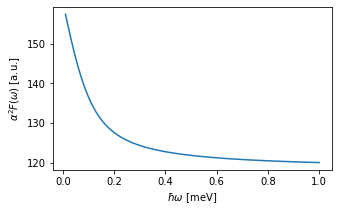

In [199]:
blockSize = 60
Nblocks = 50
omegas = np.linspace(0.01, 1, 100)
omegas = np.repeat(omegas[None, None, None, ...], nModes, axis=2 ) # Repeat 

F = np.zeros(100)
for iBlock in range(Nblocks):
    k1 = kFermi[np.random.randint(NkFermi, size=blockSize)]
    k2 = kFermi[np.random.randint(NkFermi, size=blockSize)]
    g, omegaPh, E1, E2, v1, v2 = calcEph(k1, k2)
    vHat1 = v1 * (1./np.linalg.norm(v1, axis=-1)[...,None])
    vHat2 = v2 * (1./np.linalg.norm(v2, axis=-1)[...,None])
    vFactor = 1. - np.einsum('kai,Kbi->kKab', vHat1, vHat2)
    w1 = np.abs((E1 - mu)*histogram_width)
    w2 = np.abs((E2 - mu)*histogram_width)

    omegaPh = omegaPh[..., None]/eV
    omegaPh = np.repeat(omegaPh, 100, axis=3)
    
    temperature_term = bT(omegas - omegaPh)/bT(omegas)

    #print(temperature_term)
    F += np.einsum('ka,Kb,kKxw,kKab,kKxab-> w', (w1 < 0.5), (w2 < 0.5), temperature_term, vFactor, np.abs(g)**2)
    print(iBlock+1, end=' '); sys.stdout.flush()
print()
F *= (1 /((NkTot**2)*dos0)) #factors from expression above
F *= (NkFermi**2)*1./(Nblocks*(blockSize**2)) #account for sub-sampling
F *= (2*np.pi*histogram_width**2)
#--- plot:
plt.figure(1, figsize=(5,3))

plt.plot(np.linspace(0.01, 1, 100), (1/F)*(2.42e-17)*(1e15)) # Converting from a.u. to fs
plt.ylabel(r'$\alpha^2 F(\omega)$ [a.u.]')
plt.xlabel(r'$\hbar\omega$ [meV]')